# AI use by country: the Middle East first, then the world

**How many working-age people use generative AI in each Middle East economy, and how does the region compare with the rest of the world?**

Data: Microsoft AI Economy Institute, Global AI Diffusion reports (H2 2025, Q1 2026 and Q2 2026 editions), 147 economies, four periods from H1 2025 to Q2 2026. This notebook rebuilds the processed tables, recomputes every headline figure from the raw readings and checks it against the build script output.

## 1. Load the raw readings

One row per economy, period and document. Three Microsoft reports plus news articles that print some of the same figures.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # run from the project folder
import pandas as pd
pd.set_option("display.width", 140)
raw = pd.read_csv("data/raw/ai_diffusion_readings.csv")
agg_raw = pd.read_csv("data/raw/aggregate_readings.csv")
print(raw.shape, agg_raw.shape)
print(raw.groupby("document").size().sort_values(ascending=False).to_string())

(1084, 7) (48, 5)
document
Microsoft AI Economy Institute, Global AI Diffusion Report 2026 Q1 (May 2026)                441
Microsoft AI Economy Institute, Global AI Adoption in 2025 (H2 2025 report, January 2026)    294
Microsoft AI Economy Institute, Global AI Diffusion Q2 2026 (September 2026)                 294
Pebblous, AI Usage Rankings: What Microsoft's Country Numbers Count, Sep 2026                 15
The Peninsula Qatar, 27 Sep 2026                                                              14
Microsoft Source EMEA, Sep 2026 (Switzerland release)                                          7
Middle East AI News, 25 Sep 2026                                                               7
Follow ICT, 14 May 2026                                                                        4
Jordan government news portal, AI Diffusion Index H2 2025                                      4
Enterprise DNA, 10 May 2026                                                                    2
Mic

## 2. Data checks

Row counts, missing values, duplicates, value range and coverage by period.

In [2]:
print("missing values:", int(raw[["economy", "period", "ai_diffusion_pct", "document"]].isna().sum().sum()))
print("duplicate economy-period-document rows:", int(raw.duplicated(["economy", "period", "document"]).sum()))
print("value range:", raw.ai_diffusion_pct.min(), "to", raw.ai_diffusion_pct.max())
print("economies per period:")
print(raw.groupby("period").economy.nunique().to_string())

missing values: 0
duplicate economy-period-document rows: 0
value range: 4.6 to 73.3
economies per period:
period
2025-H1    147
2025-H2    147
2026-Q1    147
2026-Q2    147


## 3. Do the documents agree?

Where two documents print a figure for the same economy and period, the figures should match. The only differences allowed are revisions of at most 0.1 point between two Microsoft reports.

In [3]:
g = raw.groupby(["economy", "period"]).ai_diffusion_pct.agg(["min", "max", "count"])
g["spread"] = (g["max"] - g["min"]).round(2)
print("figures printed in two or more documents:", int((g["count"] >= 2).sum()), "of", len(g))
print("figures where documents differ:")
print(g[g.spread > 0].to_string())
assert g.spread.max() <= 0.1

figures printed in two or more documents: 461 of 588
figures where documents differ:
                   min   max  count  spread
economy  period                            
Algeria  2026-Q1  13.2  13.3      2     0.1
Cambodia 2026-Q1   5.7   5.8      2     0.1
Gambia   2026-Q1  11.4  11.5      2     0.1
Ukraine  2026-Q1   9.4   9.5      2     0.1


The four differences are Q1 2026 values that the Q2 2026 report prints 0.1 point higher than the Q1 2026 report did. The Q2 2026 report was read twice, and both reads gave the same values, so these are treated as revisions and the later figure is used. None of them is a Middle East headline figure except Algeria (13.2% against 13.3% for Q1 2026), which does not change any finding.

## 4. Rebuild the processed tables

In [4]:
import subprocess, sys
print(subprocess.run([sys.executable, "scripts/build_data.py"], capture_output=True, text=True).stdout[-1800:])
eco = pd.read_csv("data/processed/ai_use_by_economy.csv")
tidy = pd.read_csv("data/processed/ai_use_tidy.csv")
summary = pd.read_csv("data/processed/region_summary.csv")
world = pd.read_csv("data/processed/world_aggregates.csv").set_index("period")

ates                 73.3           Kuwait                22.6                          5
Middle East: Levant and Iraq          5                       5               27.70               Israel                 38.7            Syria                 7.4                          3
   Middle East: North Africa          5                       5               13.90                Libya                 15.5          Morocco                12.0                          0
Middle East: Iran and Turkey          2                       2               15.85               Turkey                 18.9             Iran                12.8                          1
                      Europe         32                      32               30.95              Ireland                 49.9          Ukraine                 9.5                         28
                        Asia         28                      25               14.70            Singapore                 64.3         Cambodia        

## 5. Recompute the headline figures from the raw file and compare

In [5]:
q2 = raw[(raw.period == "2026-Q2") & raw.document.str.contains("Q2 2026")].set_index("economy").ai_diffusion_pct
h1 = raw[(raw.period == "2025-H1") & raw.document.str.contains("H2 2025 report")].set_index("economy").ai_diffusion_pct
w = agg_raw[(agg_raw.group == "World") & (agg_raw.period == "2026-Q2")].ai_diffusion_pct.unique()
assert len(w) == 1
WORLD = float(w[0])

me = ["United Arab Emirates", "Qatar", "Saudi Arabia", "Oman", "Kuwait", "Israel", "Jordan", "Lebanon", "Syria",
      "Iraq", "Egypt", "Libya", "Tunisia", "Algeria", "Morocco", "Iran", "Turkey"]
gulf = me[:5]
north_africa = ["Egypt", "Libya", "Tunisia", "Algeria", "Morocco"]
head = {
    "World, Q2 2026": WORLD,
    "UAE, Q2 2026": q2["United Arab Emirates"],
    "Syria, Q2 2026": q2["Syria"],
    "UAE as a multiple of the world figure": round(q2["United Arab Emirates"] / WORLD, 1),
    "Qatar, Q2 2026": q2["Qatar"],
    "Middle East economies above the world figure": int((q2[me] > WORLD).sum()),
    "Gulf economies above the world figure": int((q2[gulf] > WORLD).sum()),
    "North Africa economies above the world figure": int((q2[north_africa] > WORLD).sum()),
    "Median, Gulf": q2[gulf].median(),
    "Median, Europe": None,
    "UAE gain, H1 2025 to Q2 2026 (points)": round(q2["United Arab Emirates"] - h1["United Arab Emirates"], 1),
    "Sub-Saharan Africa economies with a shared estimate": None,
}
e = eco.set_index("economy")
head["Median, Europe"] = e[e.region == "Europe"].q2_2026_pct.median()
head["Sub-Saharan Africa economies with a shared estimate"] = int(((e.region == "Sub-Saharan Africa") & (e.own_estimate == "no")).sum())

s = summary.set_index("group")
assert WORLD == world.loc["2026-Q2", "world_pct"]
assert head["UAE, Q2 2026"] == e.loc["United Arab Emirates", "q2_2026_pct"] and e.loc["United Arab Emirates", "rank_q2_2026"] == 1
assert head["Syria, Q2 2026"] == s.loc["Middle East", "lowest_q2_2026_pct"]
assert head["Qatar, Q2 2026"] == e.loc["Qatar", "q2_2026_pct"] and e.loc["Qatar", "rank_q2_2026"] == 10
assert head["Middle East economies above the world figure"] == s.loc["Middle East", "economies_above_world_pct"]
assert head["Gulf economies above the world figure"] == s.loc["Middle East: Gulf", "economies_above_world_pct"]
assert head["North Africa economies above the world figure"] == s.loc["Middle East: North Africa", "economies_above_world_pct"]
assert head["Median, Gulf"] == s.loc["Middle East: Gulf", "median_q2_2026_pct"]
assert head["Median, Europe"] == s.loc["Europe", "median_q2_2026_pct"]
assert head["UAE gain, H1 2025 to Q2 2026 (points)"] == e.loc["United Arab Emirates", "change_h1_2025_to_q2_2026_pp"]
assert head["Sub-Saharan Africa economies with a shared estimate"] == 41 - s.loc["Sub-Saharan Africa", "economies_own_estimate"]
print("All headline figures match the build output.")
pd.Series(head, name="value").to_frame()

All headline figures match the build output.


,value
"World, Q2 2026",18.80
"UAE, Q2 2026",73.30
"Syria, Q2 2026",7.40
UAE as a multiple of the world figure,3.90
"Qatar, Q2 2026",43.50
Middle East economies above the world figure,9.00
Gulf economies above the world figure,5.00
North Africa economies above the world figure,0.00
"Median, Gulf",31.40
"Median, Europe",30.95


## 6. Middle East, Q2 2026

In [6]:
cols = ["economy", "sub_region", "h1_2025_pct", "q1_2026_pct", "q2_2026_pct", "rank_q2_2026",
        "change_q1_to_q2_pp", "change_h1_2025_to_q2_2026_pp", "q2_2026_verification"]
eco[eco.region == "Middle East"][cols].reset_index(drop=True)

,economy,sub_region,h1_2025_pct,q1_2026_pct,q2_2026_pct,rank_q2_2026,change_q1_to_q2_pp,change_h1_2025_to_q2_2026_pp,q2_2026_verification
0,United Arab Emirates,Gulf,59.4,70.1,73.3,1,3.2,13.9,two-publishers
1,Qatar,Gulf,35.7,41.8,43.5,10,1.7,7.8,two-publishers
2,Israel,Levant and Iraq,33.9,38.1,38.7,15,0.6,4.8,two-publishers
3,Saudi Arabia,Gulf,23.7,29.4,31.4,25,2.0,7.7,two-publishers
4,Jordan,Levant and Iraq,25.4,29.7,31.2,28,1.5,5.8,single-document
5,Lebanon,Levant and Iraq,24.8,27.3,27.7,34,0.4,2.9,single-document
6,Oman,Gulf,22.6,26.5,27.6,35,1.1,5.0,single-document
7,Kuwait,Gulf,17.7,21.1,22.6,52,1.5,4.9,single-document
8,Turkey,Iran and Turkey,13.4,17.4,18.9,62,1.5,5.5,single-document
9,Libya,North Africa,12.7,15.0,15.5,72,0.5,2.8,single-document


## 7. Regions, Middle East first

Medians are unweighted: each economy counts once, whatever its population. The world figure published by Microsoft is weighted by working-age population, so a region median and the world figure are not the same kind of number.

In [7]:
summary[["group", "economies", "economies_own_estimate", "median_q2_2026_pct", "highest", "highest_q2_2026_pct",
         "lowest", "lowest_q2_2026_pct", "economies_above_world_pct"]]

## 8. Which economies carry their own estimate?

Thirty-six economies have exactly the same value as their neighbours in all four periods. That is the sign of a regional estimate applied to every member, not a separate measurement for each economy. Results for these economies should be read as regional figures.

In [8]:
eco[eco.own_estimate == "no"].groupby("shared_value_group").agg(
    economies=("economy", "size"), q2_2026_pct=("q2_2026_pct", "first"),
    members=("economy", lambda s: ", ".join(s)))

## 9. Sensitivity: does the Middle East result depend on the choice of benchmark?

The main comparison uses the world figure (18.8%). The alternative uses the median of all 147 economies (15.4%), which counts each economy once.

In [9]:
med_all = eco.q2_2026_pct.median()
mee = eco[eco.region == "Middle East"]
print(f"Median of 147 economies: {med_all}")
print("Middle East economies above the world figure (18.8%):", int((mee.q2_2026_pct > WORLD).sum()), "of", len(mee))
print(f"Middle East economies above the 147-economy median ({med_all}%):", int((mee.q2_2026_pct > med_all).sum()), "of", len(mee))
print("Gulf above both:", bool((mee[mee.sub_region == "Gulf"].q2_2026_pct > max(WORLD, med_all)).all()))
print("North Africa above the 147-economy median:", int((mee[mee.sub_region == "North Africa"].q2_2026_pct > med_all).sum()), "of 5")

Median of 147 economies: 15.4
Middle East economies above the world figure (18.8%): 9 of 17
Middle East economies above the 147-economy median (15.4%): 11 of 17
Gulf above both: True
North Africa above the 147-economy median: 2 of 5


## 10. Charts

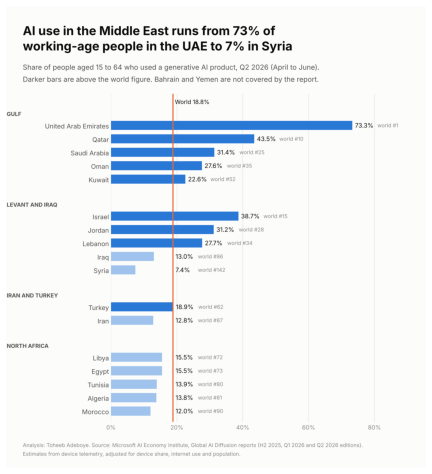

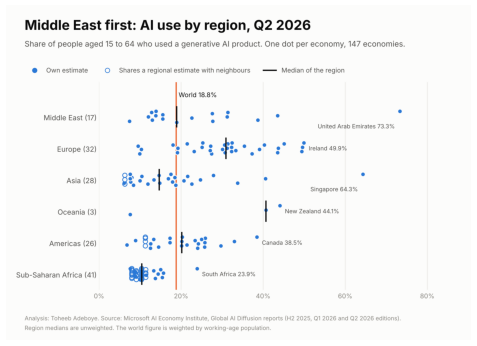

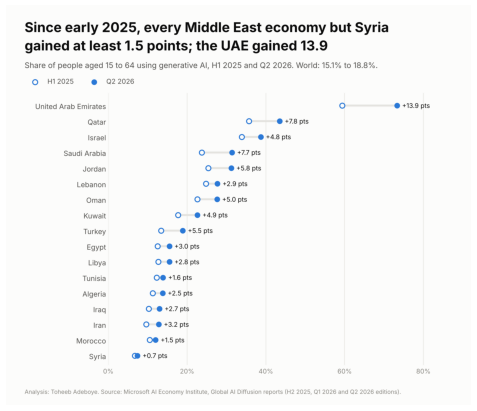

In [10]:
import subprocess, sys
subprocess.run([sys.executable, "scripts/make_charts.py"], check=True)
import matplotlib.pyplot as plt, matplotlib.image as mpimg
for f in ["ai-use-middle-east-chart.png", "ai-use-by-region.png", "ai-use-change-middle-east.png"]:
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mpimg.imread("images/" + f)); ax.axis("off")
    plt.show()

## 11. Limitations

- The figures are estimates from Microsoft device telemetry, adjusted for device market share, internet use and population. They are not a survey. Use of AI tools that send no telemetry to Microsoft is captured only through those adjustments.
- Q2 2026 values for 127 of 147 economies rest on one document, the Q2 2026 report, read twice with identical results. Earlier periods are confirmed in two Microsoft reports.
- Thirty-six economies carry a shared regional estimate.
- Bahrain, Yemen and Palestine are not in the report.